# Name:-Riddhi Manjrekar     RollNo:-42     Batch:- A-2
#Expt.-8: Clustering of Countries with World Bank API

In [29]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

In [30]:
def fetch_indicator(code, year = "2022"):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
    response = requests.get(url).json()[1]

    data = {}

    for item in response:
        country = item["country"]["value"]
        value = item["value"]
        if value is not None:
            data[country] = value

    return pd.Series(data, name=code)




In [31]:
gdp = fetch_indicator("NY.GDP.MKTP.CD")
pop = fetch_indicator("SP.POP.TOTL")
life = fetch_indicator("SP.DYN.LE00.IN")
lit = fetch_indicator("SE.ADT.LITR.ZS")


In [32]:
df = pd.concat([gdp, pop, life, lit], axis=1)
df.columns = ['GDP', 'Population', 'LifeExpectancy', 'Literacy']
df.dropna(inplace=True)
df.head()

,GDP,Population,LifeExpectancy,Literacy
Africa Eastern and Southern,1.228968e+12,731821393,64.487020,73.055977
Africa Western and Central,1.063649e+12,497387180,57.987813,60.780979
Arab World,3.747417e+12,471352066,71.876096,78.271927
Central Europe and the Baltics,1.954419e+12,100071871,76.652299,99.479919
Early-demographic dividend,1.403469e+13,3470644834,71.430455,81.242798


In [33]:

df.tail()

,GDP,Population,LifeExpectancy,Literacy
Uruguay,7.059411e+10,3390913,76.468,98.849998
Uzbekistan,9.009593e+10,34938955,72.147,100.000000
Viet Nam,4.134452e+11,99680655,74.502,96.129997
West Bank and Gaza,1.916550e+10,5043612,76.662,97.839996
Zambia,2.916378e+10,20152938,65.279,79.975143


#This was data set part 1 till here

In [34]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

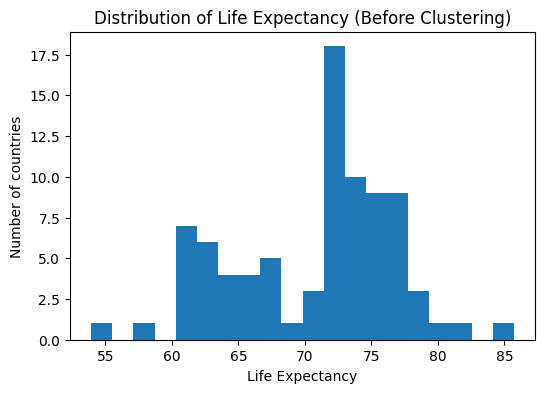

In [35]:
plt.figure(figsize=(6,4))
plt.hist(df["LifeExpectancy"], bins = 20)
plt.xlabel("Life Expectancy")
plt.ylabel("Number of countries")
plt.title("Distribution of Life Expectancy (Before Clustering)")
plt.show()


k	WCSS
1 336.0000000000001
2 213.8192086938364
3 111.2285516292643
4 84.72050726559885
5 68.05045685149851
6 49.660218157419834
7 38.584351080006684
8 36.33256837953259
9 30.584206037496223
10 26.754029454699573


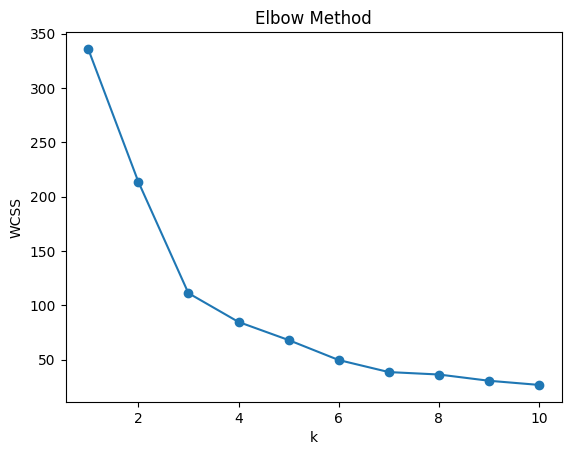

In [37]:
wcss = []

for k in range(1, 11):
  km=KMeans(n_clusters=k, random_state=42)
  km.fit(x_scaled)
  wcss.append(km.inertia_)

print("k\tWCSS")
for i in range(10):
  print(i+1, wcss[i])

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

#Clustering algorithm

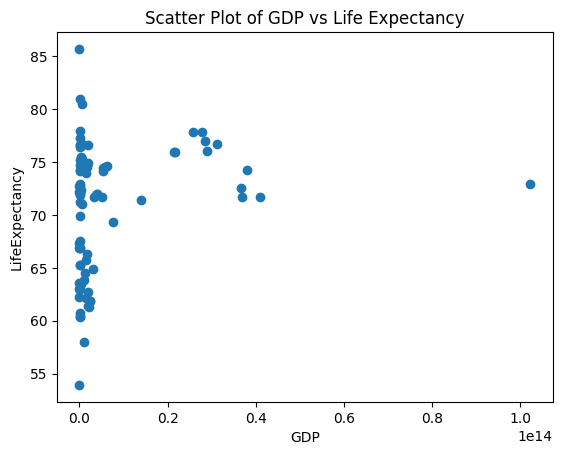

In [39]:
plt.scatter(df['GDP'],df['LifeExpectancy'])
plt.xlabel('GDP')
plt.ylabel('LifeExpectancy')
plt.title('Scatter Plot of GDP vs Life Expectancy')
plt.show()

In [42]:
kmeans = KMeans(n_clusters=3, random_state=0)
labels_km = kmeans.fit_predict(x_scaled)

df['kMeansCluster'] = labels_km

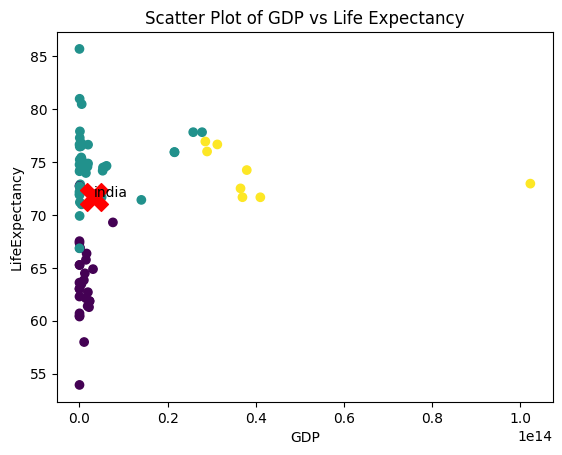

In [59]:
plt.scatter(df['GDP'],df['LifeExpectancy'],c=labels_km)
plt.xlabel('GDP')
plt.ylabel('LifeExpectancy')
plt.title('Scatter Plot of GDP vs Life Expectancy')
india = df.loc['India']
plt.scatter(india['GDP'],india['LifeExpectancy'],c='red',marker='X', label='india', s=400)
plt.text(india["GDP"], india["LifeExpectancy"],"india")

plt.show()

#Hiearchical clustering

In [46]:
hc = AgglomerativeClustering(n_clusters=3)
labels_hc = hc.fit_predict(x_scaled)

df['HCCluster'] = labels_hc

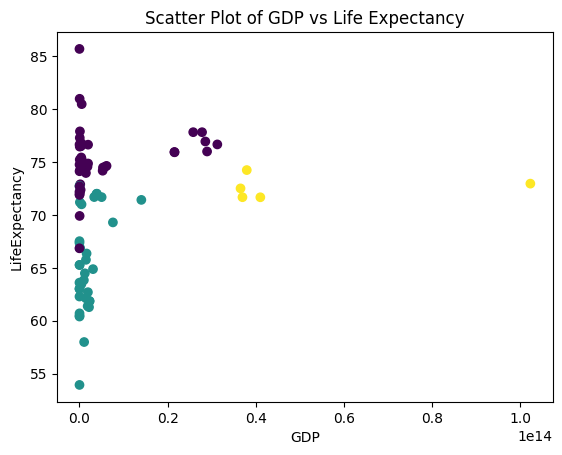

In [47]:
plt.scatter(df['GDP'],df['LifeExpectancy'], c=labels_hc)
plt.xlabel('GDP')
plt.ylabel('LifeExpectancy')
plt.title('Scatter Plot of GDP vs Life Expectancy')
plt.show()

In [49]:
cluster_summary = df.groupby('kMeansCluster')[["GDP","Population","LifeExpectancy","Literacy"]].mean()
cluster_summary

,GDP,Population,LifeExpectancy,Literacy
kMeansCluster,,,,
0,1.029297e+12,5.736557e+08,63.679633,67.141161
1,3.520736e+12,4.009111e+08,74.568088,92.446706
2,4.293310e+13,4.937925e+09,74.092408,90.542451


In [50]:
country_name="India"
result = df.loc[country_name]

print("Country : ", country_name)
print("GDP : ", result["GDP"])
print("Population : ", result["Population"])
print("Life Expectancy : ", result["LifeExpectancy"])
print("Literacy : ", result["Literacy"])
print("Cluster : ", result["kMeansCluster"])
print("HC Cluster : ",result["HCCluster"])

Country :  India
GDP :  3346107287730.93
Population :  1425423212.0
Life Expectancy :  71.698
Literacy :  76.3199996948242
Cluster :  1.0
HC Cluster :  1.0


In [51]:
country_name="North America"
result = df.loc[country_name]

print("Country : ", country_name)
print("GDP : ", result["GDP"])
print("Population : ", result["Population"])
print("Life Expectancy : ", result["LifeExpectancy"])
print("Literacy : ", result["Literacy"])
print("Cluster : ", result["kMeansCluster"])
print("HC Cluster : ",result["HCCluster"])

Country :  North America
GDP :  27803134368745.3
Population :  373018004.0
Life Expectancy :  77.8327679594239
Literacy :  98.7891464233398
Cluster :  1.0
HC Cluster :  0.0


In [52]:
country_name="Brazil"
result = df.loc[country_name]

print("Country : ", country_name)
print("GDP : ", result["GDP"])
print("Population : ", result["Population"])
print("Life Expectancy : ", result["LifeExpectancy"])
print("Literacy : ", result["Literacy"])
print("Cluster : ", result["kMeansCluster"])
print("HC Cluster : ",result["HCCluster"])

Country :  Brazil
GDP :  1951923832083.87
Population :  210306415.0
Life Expectancy :  74.872
Literacy :  94.3853874531348
Cluster :  1.0
HC Cluster :  0.0


In [53]:
country_name="Viet Nam"
result = df.loc[country_name]

print("Country : ", country_name)
print("GDP : ", result["GDP"])
print("Population : ", result["Population"])
print("Life Expectancy : ", result["LifeExpectancy"])
print("Literacy : ", result["Literacy"])
print("Cluster : ", result["kMeansCluster"])
print("HC Cluster : ",result["HCCluster"])

Country :  Viet Nam
GDP :  413445230668.578
Population :  99680655.0
Life Expectancy :  74.502
Literacy :  96.129997253418
Cluster :  1.0
HC Cluster :  0.0


In [54]:
country_name="Bahrain"
result = df.loc[country_name]

print("Country : ", country_name)
print("GDP : ", result["GDP"])
print("Population : ", result["Population"])
print("Life Expectancy : ", result["LifeExpectancy"])
print("Literacy : ", result["Literacy"])
print("Cluster : ", result["kMeansCluster"])
print("HC Cluster : ",result["HCCluster"])

Country :  Bahrain
GDP :  46458191489.3617
Population :  1524693.0
Life Expectancy :  80.992
Literacy :  97.870002746582
Cluster :  1.0
HC Cluster :  0.0
